In [155]:
import pandas as pd

In [156]:
df=pd.read_csv("/content/train.csv")
df

,text,sentiment
0,"Now, I won't deny that when I purchased this o...",neg
1,"The saddest thing about this ""tribute"" is that...",neg
2,Last night I decided to watch the prequel or s...,neg
3,I have to admit that i liked the first half of...,neg
4,I was not impressed about this film especially...,neg
...,...,...
24995,"This film is fun, if your a person who likes a...",pos
24996,After seeing this film I feel like I know just...,pos
24997,first this deserves about 5 stars due to actin...,neg
24998,If you like films that ramble with little plot...,neg


In [157]:
df.head()

,text,sentiment
0,"Now, I won't deny that when I purchased this o...",neg
1,"The saddest thing about this ""tribute"" is that...",neg
2,Last night I decided to watch the prequel or s...,neg
3,I have to admit that i liked the first half of...,neg
4,I was not impressed about this film especially...,neg


In [158]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   text       25000 non-null  object
 1   sentiment  25000 non-null  object
dtypes: object(2)
memory usage: 390.8+ KB


In [159]:
df.isnull().sum()


,0
text,0
sentiment,0


In [160]:
df["sentiment"].value_counts()

,count
sentiment,
neg,12500
pos,12500


In [161]:
df.describe()

,text,sentiment
count,25000,25000
unique,24904,2
top,"When i got this movie free from my job, along ...",neg
freq,3,12500


In [162]:
df["word_count"] = df["text"].apply(lambda x: len(x.split()))

In [163]:
df["word_count"]

,word_count
0,137
1,313
2,180
3,162
4,195
...,...
24995,49
24996,143
24997,835
24998,200


In [164]:
df["word_count"].describe()

,word_count
count,25000.000000
mean,233.787200
std,173.733032
min,10.000000
25%,127.000000
50%,174.000000
75%,284.000000
max,2470.000000


In [165]:
df["clean_text"] = df["text"].str.lower()

In [166]:
print(df["text"][0])
print(df["clean_text"][0])

Now, I won't deny that when I purchased this off eBay, I had high expectations. This was an incredible out-of-print work from the master of comedy that I so enjoy. However, I was soon to be disappointed. Apologies to those who enjoyed it, but I just found the Compleat Al to be very difficult to watch. I got a few smiles, sure, but the majority of the funny came from the music videos (which I've got on DVD) and the rest was basically filler. You could tell that this was not Al's greatest video achievement (that honor goes to UHF). Honestly, I doubt if this will ever make the jump to DVD, so if you're an ultra-hardcore Al fan and just HAVE to own everything, buy the tape off eBay. Just don't pay too much for it.
now, i won't deny that when i purchased this off ebay, i had high expectations. this was an incredible out-of-print work from the master of comedy that i so enjoy. however, i was soon to be disappointed. apologies to those who enjoyed it, but i just found the compleat al to be ve

In [167]:
import re

df["clean_text"] = df["clean_text"].apply(
    lambda x: re.sub(r"<.*?>", " ", x)
)

In [168]:
print(df["text"][6])

print("----------------")

print(df["clean_text"][6])

This was a great movie with a good cast, all of them hitting on all cylinders. And when Dianne Keaton is at her best, well, it just doesn't get any better than that. But Tom Everett Scott, always underrated, was even better. He should be a star. <br /><br />My only complaint is with one aspect of the screenplay. None of the characters ever acknowledged that the dead daughter wasn't always a good person. And neither was her mother, played by Keaton. At one point she breaks a promise she made to one character not to reveal that he had been sleeping around. <br /><br />One of the other commentators said the movie had a "political agenda". That is a baffling thing to say. There was no politics at all in this movie.
----------------
this was a great movie with a good cast, all of them hitting on all cylinders. and when dianne keaton is at her best, well, it just doesn't get any better than that. but tom everett scott, always underrated, was even better. he should be a star.   my only compla

In [169]:
!pip install contractions

In [170]:
import contractions

df["clean_text"] = df["clean_text"].apply(
    lambda x: contractions.fix(x)
)

In [171]:
df["clean_text"] = df["clean_text"].apply(
    lambda x: re.sub(r"http\S+|www\S+", " ", x)
)

In [172]:
df["clean_text"] = df["clean_text"].apply(
    lambda x: re.sub(r"[^\w\s]", " ", x)
)

In [173]:
df["clean_text"] = df["clean_text"].apply(
    lambda x: re.sub(r"\s+", " ", x).strip()
)

In [174]:
print(df["text"][6])

print("----------------")

print(df["clean_text"][6])

This was a great movie with a good cast, all of them hitting on all cylinders. And when Dianne Keaton is at her best, well, it just doesn't get any better than that. But Tom Everett Scott, always underrated, was even better. He should be a star. <br /><br />My only complaint is with one aspect of the screenplay. None of the characters ever acknowledged that the dead daughter wasn't always a good person. And neither was her mother, played by Keaton. At one point she breaks a promise she made to one character not to reveal that he had been sleeping around. <br /><br />One of the other commentators said the movie had a "political agenda". That is a baffling thing to say. There was no politics at all in this movie.
----------------
this was a great movie with a good cast all of them hitting on all cylinders and when dianne keaton is at her best well it just does not get any better than that but tom everett scott always underrated was even better he should be a star my only complaint is wit

In [175]:
import nltk

nltk.download("punkt")
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [176]:
from nltk.tokenize import word_tokenize

df["tokens"] = df["clean_text"].apply(word_tokenize)

In [177]:
print(df["tokens"][2])

['last', 'night', 'i', 'decided', 'to', 'watch', 'the', 'prequel', 'or', 'shall', 'i', 'say', 'the', 'so', 'called', 'prequel', 'to', 'carlito', 's', 'way', 'carlito', 's', 'way', 'rise', 'to', 'power', '2005', 'which', 'went', 'straight', 'to', 'dvd', 'no', 'wonder', 'it', 'completely', 'and', 'i', 'mean', 'completely', 's', 'ks', 'waist', 'of', 'time', 'watching', 'it', 'and', 'i', 'think', 'it', 'would', 'be', 'a', 'pure', 'waist', 'of', 'time', 'writing', 'about', 'it', 'i', 'do', 'not', 'understand', 'how', 'de', 'palma', 'agreed', 'on', 'producing', 'this', 'sh', 't', 'fest', 'of', 'a', 'movie', 'except', 'for', 'only', 'one', 'fact', 'that', 'i', 'tip', 'my', 'hat', 'to', 'jay', 'hernandez', 'who', 'plays', 'the', 'young', 'brigante', 'reminded', 'me', 'how', 'de', 'niro', 'got', 'into', 'the', 'shoes', 'of', 'brando', 'to', 'portray', 'the', 'young', 'don', 'corleone', 'in', 'godfather', 'ii', 'but', 'the', 'difference', 'de', 'niro', 'was', 'amazing', 'and', 'even', 'got', 'an

In [178]:
df.head()

,text,sentiment,word_count,clean_text,tokens
0,"Now, I won't deny that when I purchased this o...",neg,137,now i will not deny that when i purchased this...,"[now, i, will, not, deny, that, when, i, purch..."
1,"The saddest thing about this ""tribute"" is that...",neg,313,the saddest thing about this tribute is that a...,"[the, saddest, thing, about, this, tribute, is..."
2,Last night I decided to watch the prequel or s...,neg,180,last night i decided to watch the prequel or s...,"[last, night, i, decided, to, watch, the, preq..."
3,I have to admit that i liked the first half of...,neg,162,i have to admit that i liked the first half of...,"[i, have, to, admit, that, i, liked, the, firs..."
4,I was not impressed about this film especially...,neg,195,i was not impressed about this film especially...,"[i, was, not, impressed, about, this, film, es..."


In [179]:
from nltk.corpus import stopwords

nltk.download("stopwords")

stop_words = set(stopwords.words("english"))

df["tokens"] = df["tokens"].apply(
    lambda words: [word for word in words if word not in stop_words]
)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [180]:
df.head()

,text,sentiment,word_count,clean_text,tokens
0,"Now, I won't deny that when I purchased this o...",neg,137,now i will not deny that when i purchased this...,"[deny, purchased, ebay, high, expectations, in..."
1,"The saddest thing about this ""tribute"" is that...",neg,313,the saddest thing about this tribute is that a...,"[saddest, thing, tribute, almost, singers, inc..."
2,Last night I decided to watch the prequel or s...,neg,180,last night i decided to watch the prequel or s...,"[last, night, decided, watch, prequel, shall, ..."
3,I have to admit that i liked the first half of...,neg,162,i have to admit that i liked the first half of...,"[admit, liked, first, half, sleepers, looked, ..."
4,I was not impressed about this film especially...,neg,195,i was not impressed about this film especially...,"[impressed, film, especially, fact, went, cine..."


---

---

---

In [181]:
import nltk
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('averaged_perceptron_tagger_eng')
from nltk import pos_tag

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


In [182]:
from nltk.corpus import wordnet

def get_wordnet_pos(tag):

    if tag.startswith('J'):
        return wordnet.ADJ

    elif tag.startswith('V'):
        return wordnet.VERB

    elif tag.startswith('N'):
        return wordnet.NOUN

    elif tag.startswith('R'):
        return wordnet.ADV

    else:
        return wordnet.NOUN

In [183]:
from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()

In [184]:
def pos_lemmatize(tokens):

    tagged = pos_tag(tokens)

    lemmas = []

    for word, tag in tagged:

        pos = get_wordnet_pos(tag)

        lemma = lemmatizer.lemmatize(word, pos)

        lemmas.append(lemma)

    return lemmas

In [185]:
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [186]:
df["tokens_pos"] = df["tokens"].apply(pos_lemmatize)

In [187]:
print(df["tokens_pos"][0])

['deny', 'purchase', 'ebay', 'high', 'expectation', 'incredible', 'print', 'work', 'master', 'comedy', 'enjoy', 'however', 'soon', 'disappointed', 'apology', 'enjoy', 'find', 'compleat', 'al', 'difficult', 'watch', 'get', 'smile', 'sure', 'majority', 'funny', 'come', 'music', 'video', 'get', 'dvd', 'rest', 'basically', 'filler', 'could', 'tell', 'al', 'great', 'video', 'achievement', 'honor', 'go', 'uhf', 'honestly', 'doubt', 'ever', 'make', 'jump', 'dvd', 'ultra', 'hardcore', 'al', 'fan', 'everything', 'buy', 'tape', 'ebay', 'pay', 'much']


In [188]:
df["processed_text"] = df["tokens_pos"].apply(lambda words: " ".join(words))

In [189]:
print(df["processed_text"][0])

deny purchase ebay high expectation incredible print work master comedy enjoy however soon disappointed apology enjoy find compleat al difficult watch get smile sure majority funny come music video get dvd rest basically filler could tell al great video achievement honor go uhf honestly doubt ever make jump dvd ultra hardcore al fan everything buy tape ebay pay much


In [190]:
print(df[["tokens_pos", "processed_text"]].head())

                                          tokens_pos  \
0  [deny, purchase, ebay, high, expectation, incr...   
1  [sad, thing, tribute, almost, singer, include,...   
2  [last, night, decide, watch, prequel, shall, s...   
3  [admit, like, first, half, sleeper, look, good...   
4  [impressed, film, especially, fact, go, cinema...   

                                      processed_text  
0  deny purchase ebay high expectation incredible...  
1  sad thing tribute almost singer include otherw...  
2  last night decide watch prequel shall say call...  
3  admit like first half sleeper look good act ev...  
4  impressed film especially fact go cinema famil...  


In [191]:
df.columns

Index(['text', 'sentiment', 'word_count', 'clean_text', 'tokens', 'tokens_pos',
       'processed_text'],
      dtype='object')

In [192]:
!pip install gensim

In [193]:
from gensim.models import Word2Vec

In [194]:
df["tokens_pos"]

,tokens_pos
0,"[deny, purchase, ebay, high, expectation, incr..."
1,"[sad, thing, tribute, almost, singer, include,..."
2,"[last, night, decide, watch, prequel, shall, s..."
3,"[admit, like, first, half, sleeper, look, good..."
4,"[impressed, film, especially, fact, go, cinema..."
...,...
24995,"[film, fun, person, like, good, campy, feature..."
24996,"[see, film, feel, like, know, little, bit, usa..."
24997,"[first, deserve, 5, star, due, act, would, giv..."
24998,"[like, film, ramble, little, plot, exposition,..."


In [195]:
model_w2v = Word2Vec(
    sentences=df["tokens_pos"],
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    sg=1
)

In [196]:
model_w2v.wv.most_similar("movie")

[('film', 0.8860382437705994),
 ('defiantly', 0.8246423006057739),
 ('reviews', 0.8221139907836914),
 ('definately', 0.8168385028839111),
 ('summation', 0.8164049386978149),
 ('sooooo', 0.8107989430427551),
 ('gymkata', 0.8101871013641357),
 ('therefor', 0.8097009658813477),
 ('reiterate', 0.8076356649398804),
 ('expected', 0.8036882281303406)]

In [197]:
model_w2v.wv.most_similar("good")

[('decent', 0.813891589641571),
 ('great', 0.7773964405059814),
 ('darn', 0.7764298319816589),
 ('alright', 0.7760939598083496),
 ('feelgood', 0.7748510837554932),
 ('downside', 0.7739701867103577),
 ('workable', 0.7721450924873352),
 ('decently', 0.7716429233551025),
 ('bits', 0.7709636092185974),
 ('directer', 0.7698460817337036)]

In [198]:
model_w2v.wv.most_similar("bad")

[('cheesiest', 0.851486086845398),
 ('terrible', 0.8219319581985474),
 ('stupidest', 0.7985589504241943),
 ('sucked', 0.7966454029083252),
 ('displeasure', 0.7965169548988342),
 ('awful', 0.7961065173149109),
 ('dumbest', 0.7795200943946838),
 ('horrible', 0.7753815650939941),
 ('appalling', 0.769514799118042),
 ('suck', 0.768197238445282)]

In [199]:
print(df["clean_text"].iloc[0])

now i will not deny that when i purchased this off ebay i had high expectations this was an incredible out of print work from the master of comedy that i so enjoy however i was soon to be disappointed apologies to those who enjoyed it but i just found the compleat al to be very difficult to watch i got a few smiles sure but the majority of the funny came from the music videos which i have got on dvd and the rest was basically filler you could tell that this was not al s greatest video achievement that honor goes to uhf honestly i doubt if this will ever make the jump to dvd so if you are an ultra hardcore al fan and just have to own everything buy the tape off ebay just do not pay too much for it


In [200]:
"movieits" in model_w2v.wv

False

In [201]:
df[df["processed_text"].str.contains("movieits", na=False)]

,text,sentiment,word_count,clean_text,tokens,tokens_pos,processed_text


In [202]:
df[df["clean_text"].str.contains("movieits", na=False)]

,text,sentiment,word_count,clean_text,tokens,tokens_pos,processed_text


In [203]:
import numpy as np

def document_vector(words, model):
    vectors = []

    for word in words:
        if word in model.wv:
            vectors.append(model.wv[word])

    if len(vectors) == 0:
        return np.zeros(model.vector_size)

    return np.mean(vectors, axis=0)

In [204]:
df["tokens_pos"]

,tokens_pos
0,"[deny, purchase, ebay, high, expectation, incr..."
1,"[sad, thing, tribute, almost, singer, include,..."
2,"[last, night, decide, watch, prequel, shall, s..."
3,"[admit, like, first, half, sleeper, look, good..."
4,"[impressed, film, especially, fact, go, cinema..."
...,...
24995,"[film, fun, person, like, good, campy, feature..."
24996,"[see, film, feel, like, know, little, bit, usa..."
24997,"[first, deserve, 5, star, due, act, would, giv..."
24998,"[like, film, ramble, little, plot, exposition,..."


In [205]:
X = np.array(
    df["tokens_pos"].apply(lambda words: document_vector(words, model_w2v)).tolist()
)

In [206]:
print(X.shape)

(25000, 100)


---
---
---

---
---
---

In [207]:
# from sklearn.feature_extraction.text import TfidfVectorizer

In [208]:
# tfidf = TfidfVectorizer(max_features=5000)

In [209]:
# X = tfidf.fit_transform(df["processed_text"])

In [210]:
# X

In [211]:
# df["processed_text"]

In [212]:
y = df["sentiment"]

In [213]:
df

,text,sentiment,word_count,clean_text,tokens,tokens_pos,processed_text
0,"Now, I won't deny that when I purchased this o...",neg,137,now i will not deny that when i purchased this...,"[deny, purchased, ebay, high, expectations, in...","[deny, purchase, ebay, high, expectation, incr...",deny purchase ebay high expectation incredible...
1,"The saddest thing about this ""tribute"" is that...",neg,313,the saddest thing about this tribute is that a...,"[saddest, thing, tribute, almost, singers, inc...","[sad, thing, tribute, almost, singer, include,...",sad thing tribute almost singer include otherw...
2,Last night I decided to watch the prequel or s...,neg,180,last night i decided to watch the prequel or s...,"[last, night, decided, watch, prequel, shall, ...","[last, night, decide, watch, prequel, shall, s...",last night decide watch prequel shall say call...
3,I have to admit that i liked the first half of...,neg,162,i have to admit that i liked the first half of...,"[admit, liked, first, half, sleepers, looked, ...","[admit, like, first, half, sleeper, look, good...",admit like first half sleeper look good act ev...
4,I was not impressed about this film especially...,neg,195,i was not impressed about this film especially...,"[impressed, film, especially, fact, went, cine...","[impressed, film, especially, fact, go, cinema...",impressed film especially fact go cinema famil...
...,...,...,...,...,...,...,...
24995,"This film is fun, if your a person who likes a...",pos,49,this film is fun if your a person who likes a ...,"[film, fun, person, likes, good, campy, featur...","[film, fun, person, like, good, campy, feature...",film fun person like good campy feature film e...
24996,After seeing this film I feel like I know just...,pos,143,after seeing this film i feel like i know just...,"[seeing, film, feel, like, know, little, bit, ...","[see, film, feel, like, know, little, bit, usa...",see film feel like know little bit usa david l...
24997,first this deserves about 5 stars due to actin...,neg,835,first this deserves about 5 stars due to actin...,"[first, deserves, 5, stars, due, acting, would...","[first, deserve, 5, star, due, act, would, giv...",first deserve 5 star due act would give well s...
24998,If you like films that ramble with little plot...,neg,200,if you like films that ramble with little plot...,"[like, films, ramble, little, plot, exposition...","[like, film, ramble, little, plot, exposition,...",like film ramble little plot exposition spice ...


In [214]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y = encoder.fit_transform(y)

In [215]:
print(X.shape)

print(y[:10])

(25000, 100)
[0 0 0 0 0 1 1 0 1 0]


In [216]:
df.columns

Index(['text', 'sentiment', 'word_count', 'clean_text', 'tokens', 'tokens_pos',
       'processed_text'],
      dtype='object')

In [217]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [218]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [219]:
print(X_train.shape)
print(X_test.shape)

(20000, 100)
(5000, 100)


In [220]:
y_pred = model.predict(X_test)

In [221]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.861


Accuracy: 0.861
Precision: 0.8539944903581267
Recall: 0.8700882117080995
F1-Score: 0.8619662363455809


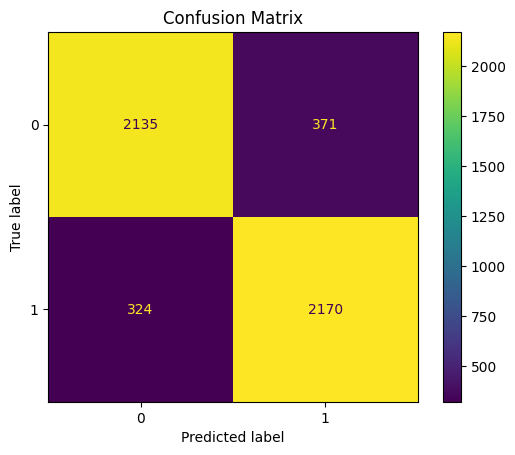


Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.85      0.86      2506
           1       0.85      0.87      0.86      2494

    accuracy                           0.86      5000
   macro avg       0.86      0.86      0.86      5000
weighted avg       0.86      0.86      0.86      5000



In [222]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Precision
precision = precision_score(y_test, y_pred)
print("Precision:", precision)

# Recall
recall = recall_score(y_test, y_pred)
print("Recall:", recall)

# F1-Score
f1 = f1_score(y_test, y_pred)
print("F1-Score:", f1)

ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)

plt.title("Confusion Matrix")
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

In [223]:
review =""""
This movie was terrible.
The story was boring and the acting was awful.
I regret watching it.
"""

In [224]:
import re
import contractions
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

def preprocess(text):

    # Lowercase
    text = text.lower()

    # Remove HTML
    text = re.sub(r"<.*?>", " ", text)

    # Expand contractions
    text = contractions.fix(text)

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", " ", text)

    # Remove punctuation
    text = re.sub(r"[^\w\s]", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    # Tokenization
    tokens = word_tokenize(text)

    # Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]

    # POS + Lemmatization
    tokens = pos_lemmatize(tokens)

    return tokens

In [225]:
processed_review = preprocess(review)

In [226]:
print(processed_review)

['movie', 'terrible', 'story', 'bore', 'act', 'awful', 'regret', 'watching']


In [227]:
vector = document_vector(processed_review, model_w2v)

In [228]:
vector = vector.reshape(1, -1)

In [229]:
prediction = model.predict(vector)

In [230]:
if prediction[0] == 1:
    print("Positive Review 😊")
else:
    print("Negative Review 😞")

Negative Review 😞


---

---

---

In [231]:
import joblib

joblib.dump(model, "sentiment_model.pkl")

['sentiment_model.pkl']

In [232]:
model_w2v.save("word2vec.model")

In [233]:
encoder = LabelEncoder()

In [234]:
joblib.dump(encoder, "label_encoder.pkl")

['label_encoder.pkl']